# 04 - Training EfficientNet-B5 (Teacher CNN)

Training del modello EfficientNet-B5 per la classificazione della Retinopatia Diabetica.

**Fase 1 del progetto**: Teacher CNN Training

**Obiettivi**:
- Training EfficientNet-B5 pretrained su ImageNet
- Focal Loss + Label Smoothing per gestire class imbalance
- Target: Accuracy >= 90% su validation set

**Output**:
- Modello trained salvato in `checkpoints/`
- Training history e metriche

## 1. Import e Configurazione

In [1]:
import os
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
import json

# Manipolazione dati
import pandas as pd
import numpy as np

# Configurazione
import yaml

# Deep Learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast
from torch.optim.lr_scheduler import CosineAnnealingLR, CosineAnnealingWarmRestarts, StepLR, ReduceLROnPlateau, OneCycleLR

# Modelli pretrained
import timm

# Elaborazione immagini
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Metriche
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, classification_report

# Visualizzazione
import matplotlib.pyplot as plt
import seaborn as sns

# Progress bar
from tqdm.auto import tqdm

# Impostazioni visualizzazione
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponibile: {torch.cuda.is_available()}")

PyTorch version: 2.9.1+cu130
CUDA disponibile: True


In [2]:
def get_project_root():
    """
    Rileva la root del progetto.
    Funziona sia su Windows che su WSL.
    """
    notebook_dir = Path.cwd()
    if notebook_dir.name == 'notebooks':
        return notebook_dir.parent
    current = notebook_dir
    for _ in range(5):
        if (current / 'Data').exists():
            return current
        current = current.parent
    if sys.platform == 'linux' and Path('/mnt/c').exists():
        return Path('/mnt/c/Repository/multi-method-xai-diabetic-retinopathy')
    return Path('C:/Repository/multi-method-xai-diabetic-retinopathy')


PROJECT_ROOT = get_project_root()
print(f"Project root: {PROJECT_ROOT}")

Project root: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy


In [3]:
# Caricamento configurazione
config_path = PROJECT_ROOT / 'config.yaml'
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# Setup percorsi
DATA_DIR = PROJECT_ROOT / config['paths']['data_dir']
PROCESSED_DIR = PROJECT_ROOT / config['paths']['processed_dir']
PREPROCESSED_DIR = PROJECT_ROOT / config['paths']['preprocessed_images']
RESULTS_DIR = PROJECT_ROOT / config['paths']['results_dir']
CHECKPOINTS_DIR = PROJECT_ROOT / config['paths']['checkpoints_dir']
LOGS_DIR = PROJECT_ROOT / config['paths']['logs_dir']

# Crea directory
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

# Seed per riproducibilita
SEED = config['seed']
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device: {DEVICE}")
print(f"Seed: {SEED}")

Device: cuda
Seed: 42


In [4]:
# Estrazione parametri dal config
MODEL_CONFIG = config['model']
TRAIN_CONFIG = config['training']
LOADER_CONFIG = config['dataloader']
AUG_CONFIG = config['augmentation']

# Parametri principali
NUM_CLASSES = MODEL_CONFIG['num_classes']
CLASS_NAMES = MODEL_CONFIG['class_names']
EPOCHS = TRAIN_CONFIG['epochs']
BATCH_SIZE = LOADER_CONFIG['batch_size']

print("Configurazione Training")
print("=" * 60)
print(f"Architettura: {MODEL_CONFIG['architecture']}")
print(f"Classi: {NUM_CLASSES}")
print(f"Epoche: {EPOCHS}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {TRAIN_CONFIG['optimizer']['lr']}")
print(f"Loss: {TRAIN_CONFIG['loss']['name']}")
print(f"Label smoothing: {TRAIN_CONFIG['loss']['label_smoothing']}")
print(f"Mixed precision (AMP): {TRAIN_CONFIG['use_amp']}")
print(f"Freeze backbone: {MODEL_CONFIG['freeze']['enabled']} ({MODEL_CONFIG['freeze']['epochs']} epoche)")

Configurazione Training
Architettura: efficientnet_b5
Classi: 5
Epoche: 30
Batch size: 16
Learning rate: 0.0001
Loss: focal
Label smoothing: 0.1
Mixed precision (AMP): True
Freeze backbone: True (3 epoche)


## 2. Caricamento Dataset e DataLoader

In [5]:
# Carica i CSV con i percorsi delle immagini preprocessate
train_csv = PROCESSED_DIR / 'combined_train_preprocessed.csv'
val_csv = PROCESSED_DIR / 'aptos_preprocessed.csv'
test_csv = PROCESSED_DIR / 'messidor2_preprocessed.csv'

train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
val_df = val_df[val_df['split'] == 'valid']  # Solo validation set APTOS
test_df = pd.read_csv(test_csv)

print("Dataset caricati:")
print(f"  Train: {len(train_df):,} immagini")
print(f"  Validation: {len(val_df):,} immagini")
print(f"  Test (Messidor-2): {len(test_df):,} immagini")

Dataset caricati:
  Train: 37,567 immagini
  Validation: 366 immagini
  Test (Messidor-2): 1,744 immagini


In [6]:
# Distribuzione classi
print("\nDistribuzione classi - Training set:")
class_counts = train_df['diagnosis'].value_counts().sort_index()
for cls, count in class_counts.items():
    pct = count / len(train_df) * 100
    print(f"  Classe {cls} ({CLASS_NAMES[cls]}): {count:,} ({pct:.1f}%)")


Distribuzione classi - Training set:
  Classe 0 (No DR): 26,952 (71.7%)
  Classe 1 (Mild): 2,716 (7.2%)
  Classe 2 (Moderate): 5,998 (16.0%)
  Classe 3 (Severe): 1,011 (2.7%)
  Classe 4 (Proliferative): 890 (2.4%)


In [7]:
def get_train_transforms(cfg):
    """
    Pipeline di augmentation per il training.
    
    Trasformazioni:
    - Flip orizzontale e verticale
    - Rotazione
    - Variazioni di colore
    - Normalizzazione ImageNet
    """
    aug_cfg = cfg['augmentation']
    
    return A.Compose([
        A.HorizontalFlip(p=0.5 if aug_cfg['horizontal_flip'] else 0),
        A.VerticalFlip(p=0.5 if aug_cfg['vertical_flip'] else 0),
        A.Rotate(
            limit=aug_cfg['rotation_limit'],
            border_mode=cv2.BORDER_CONSTANT,
            value=0,
            p=aug_cfg['prob_geometric']
        ),
        A.OneOf([
            A.RandomBrightnessContrast(
                brightness_limit=aug_cfg['brightness_limit'],
                contrast_limit=aug_cfg['contrast_limit'],
                p=1.0
            ),
            A.HueSaturationValue(
                hue_shift_limit=aug_cfg['hue_shift_limit'],
                sat_shift_limit=int(aug_cfg['saturation_limit'] * 100),
                val_shift_limit=int(aug_cfg['brightness_limit'] * 100),
                p=1.0
            ),
        ], p=aug_cfg['prob_color']),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


def get_val_transforms():
    """
    Pipeline per validation/test (solo normalizzazione).
    """
    return A.Compose([
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
        ToTensorV2()
    ])


train_transforms = get_train_transforms(config)
val_transforms = get_val_transforms()
print("Pipeline di trasformazione create.")

Pipeline di trasformazione create.


In [8]:
class DRDataset(Dataset):
    """
    Dataset PyTorch per la classificazione DR.
    
    Args:
        dataframe: DataFrame con colonne 'preprocessed_path' e 'diagnosis'
        transform: Pipeline Albumentations
        project_root: Path alla root del progetto
    """
    
    def __init__(self, dataframe, transform=None, project_root=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.project_root = project_root
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Percorso immagine
        img_path = row['preprocessed_path']
        if self.project_root and not Path(img_path).is_absolute():
            img_path = self.project_root / img_path
        
        # Carica immagine
        image = cv2.imread(str(img_path))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Applica trasformazioni
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        
        # Label
        label = torch.tensor(row['diagnosis'], dtype=torch.long)
        
        return image, label
    
    def get_labels(self):
        """Ritorna tutte le label."""
        return self.df['diagnosis'].values

In [9]:
# Crea dataset
train_dataset = DRDataset(train_df, transform=train_transforms, project_root=PROJECT_ROOT)
val_dataset = DRDataset(val_df, transform=val_transforms, project_root=PROJECT_ROOT)
test_dataset = DRDataset(test_df, transform=val_transforms, project_root=PROJECT_ROOT)

print(f"Dataset creati:")
print(f"  Train: {len(train_dataset):,} campioni")
print(f"  Validation: {len(val_dataset):,} campioni")
print(f"  Test: {len(test_dataset):,} campioni")

Dataset creati:
  Train: 37,567 campioni
  Validation: 366 campioni
  Test: 1,744 campioni


In [10]:
def compute_class_weights(labels):
    """
    Calcola i pesi delle classi per bilanciare la loss.
    Formula: weight[c] = n_samples / (n_classes * n_samples[c])
    """
    class_counts = np.bincount(labels)
    n_samples = len(labels)
    n_classes = len(class_counts)
    weights = n_samples / (n_classes * class_counts)
    return torch.FloatTensor(weights)


def create_weighted_sampler(labels):
    """
    Crea WeightedRandomSampler per oversampling classi minoritarie.
    """
    class_counts = np.bincount(labels)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[labels]
    sample_weights = torch.DoubleTensor(sample_weights)
    
    return WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )


# Calcola class weights
train_labels = train_dataset.get_labels()
class_weights = compute_class_weights(train_labels).to(DEVICE)

print("Class weights per la loss:")
for i, w in enumerate(class_weights):
    print(f"  Classe {i} ({CLASS_NAMES[i]}): {w:.4f}")

Class weights per la loss:
  Classe 0 (No DR): 0.2788
  Classe 1 (Mild): 2.7663
  Classe 2 (Moderate): 1.2527
  Classe 3 (Severe): 7.4317
  Classe 4 (Proliferative): 8.4420


In [11]:
# Setup sampler
if TRAIN_CONFIG['use_oversampling']:
    train_sampler = create_weighted_sampler(train_labels)
    shuffle_train = False
    print("Weighted sampler attivo per oversampling.")
else:
    train_sampler = None
    shuffle_train = LOADER_CONFIG['shuffle_train']
    print("Uso class weights nella loss (no oversampling).")

# Crea DataLoader
num_workers = LOADER_CONFIG['num_workers']
pin_memory = LOADER_CONFIG['pin_memory'] and torch.cuda.is_available()

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=shuffle_train,
    sampler=train_sampler,
    num_workers=num_workers,
    pin_memory=pin_memory,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=pin_memory
)

print(f"\nDataLoader creati:")
print(f"  Train: {len(train_loader)} batch")
print(f"  Validation: {len(val_loader)} batch")
print(f"  Test: {len(test_loader)} batch")

Uso class weights nella loss (no oversampling).

DataLoader creati:
  Train: 2347 batch
  Validation: 23 batch
  Test: 109 batch


## 3. Definizione Modello

In [12]:
def create_model(model_config, num_classes):
    """
    Crea il modello EfficientNet-B5 con classificatore personalizzato.
    
    Args:
        model_config: Configurazione del modello da config.yaml
        num_classes: Numero di classi di output
        
    Returns:
        model: Modello PyTorch
    """
    # Carica modello pretrained da timm
    model = timm.create_model(
        model_config['architecture'],
        pretrained=model_config['pretrained'],
        num_classes=num_classes,
        drop_rate=model_config['dropout_rate']
    )
    
    return model


def freeze_backbone(model, freeze_config):
    """
    Congela i layer del backbone per fine-tuning graduale.
    
    Args:
        model: Modello PyTorch
        freeze_config: Configurazione freeze da config.yaml
    """
    import re
    
    pattern = freeze_config.get('pattern', '')
    
    for name, param in model.named_parameters():
        # Non congelare il classificatore
        if 'classifier' in name or 'fc' in name or 'head' in name:
            param.requires_grad = True
        elif pattern:
            # Congela solo i layer che matchano il pattern
            if re.search(pattern, name):
                param.requires_grad = False
        else:
            # Congela tutto il backbone
            param.requires_grad = False


def unfreeze_backbone(model):
    """
    Scongela tutti i layer del modello.
    """
    for param in model.parameters():
        param.requires_grad = True


def count_parameters(model):
    """
    Conta i parametri del modello.
    
    Returns:
        total: Parametri totali
        trainable: Parametri trainabili
    """
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

In [13]:
# Crea modello
model = create_model(MODEL_CONFIG, NUM_CLASSES)
model = model.to(DEVICE)

# Conta parametri prima del freeze
total_params, trainable_params = count_parameters(model)
print(f"Modello: {MODEL_CONFIG['architecture']}")
print(f"Parametri totali: {total_params:,}")
print(f"Parametri trainabili: {trainable_params:,}")

Modello: efficientnet_b5
Parametri totali: 28,351,029
Parametri trainabili: 28,351,029


In [14]:
# Freeze backbone se configurato
FREEZE_CONFIG = MODEL_CONFIG['freeze']
FREEZE_EPOCHS = FREEZE_CONFIG['epochs'] if FREEZE_CONFIG['enabled'] else 0

if FREEZE_CONFIG['enabled']:
    freeze_backbone(model, FREEZE_CONFIG)
    total_params, trainable_params = count_parameters(model)
    print(f"\nBackbone congelato per {FREEZE_EPOCHS} epoche")
    print(f"Parametri trainabili dopo freeze: {trainable_params:,}")
else:
    print("\nBackbone non congelato - training end-to-end")


Backbone congelato per 3 epoche
Parametri trainabili dopo freeze: 1,058,821


## 4. Loss Function: Focal Loss + Label Smoothing

In [15]:
class FocalLoss(nn.Module):
    """
    Focal Loss per gestire il class imbalance.
    
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    
    Args:
        gamma: Focusing parameter (default: 2.0)
        alpha: Class weights (None per uniform)
        label_smoothing: Label smoothing factor (default: 0.0)
        reduction: 'mean' o 'sum'
    """
    
    def __init__(self, gamma=2.0, alpha=None, label_smoothing=0.0, reduction='mean'):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.label_smoothing = label_smoothing
        self.reduction = reduction
        
    def forward(self, inputs, targets):
        """
        Args:
            inputs: Logits (B, C)
            targets: Labels (B,)
        """
        num_classes = inputs.size(1)
        
        # Label smoothing
        if self.label_smoothing > 0:
            with torch.no_grad():
                targets_smooth = torch.zeros_like(inputs)
                targets_smooth.fill_(self.label_smoothing / (num_classes - 1))
                targets_smooth.scatter_(1, targets.unsqueeze(1), 1.0 - self.label_smoothing)
        else:
            targets_smooth = F.one_hot(targets, num_classes).float()
        
        # Softmax probabilities
        p = F.softmax(inputs, dim=1)
        
        # Focal weight: (1 - p_t)^gamma
        p_t = (p * targets_smooth).sum(dim=1)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Cross entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        
        # Focal loss
        focal_loss = focal_weight * ce_loss
        
        # Alpha weighting per classe
        if self.alpha is not None:
            alpha_t = self.alpha[targets]
            focal_loss = alpha_t * focal_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        return focal_loss

In [16]:
def create_loss_function(loss_config, class_weights=None):
    """
    Crea la loss function basata sulla configurazione.
    
    Args:
        loss_config: Configurazione loss da config.yaml
        class_weights: Pesi delle classi (opzionale)
        
    Returns:
        criterion: Loss function
    """
    loss_name = loss_config['name']
    label_smoothing = loss_config.get('label_smoothing', 0.0)
    
    if loss_name == 'focal':
        gamma = loss_config.get('gamma', 2.0)
        criterion = FocalLoss(
            gamma=gamma,
            alpha=class_weights,
            label_smoothing=label_smoothing
        )
        print(f"Loss: Focal Loss (gamma={gamma}, smoothing={label_smoothing})")
    else:
        criterion = nn.CrossEntropyLoss(
            weight=class_weights,
            label_smoothing=label_smoothing
        )
        print(f"Loss: CrossEntropyLoss (smoothing={label_smoothing})")
    
    return criterion


# Crea loss function
criterion = create_loss_function(
    TRAIN_CONFIG['loss'],
    class_weights if TRAIN_CONFIG['use_class_weights'] else None
)

Loss: Focal Loss (gamma=2.0, smoothing=0.1)


## 5. Optimizer e Scheduler

In [17]:
def create_optimizer(model, optimizer_config):
    """
    Crea l'optimizer basato sulla configurazione.
    
    Args:
        model: Modello PyTorch
        optimizer_config: Configurazione optimizer da config.yaml
        
    Returns:
        optimizer: PyTorch optimizer
    """
    opt_name = optimizer_config['name'].lower()
    lr = optimizer_config['lr']
    weight_decay = optimizer_config['weight_decay']
    
    # Filtra solo i parametri trainabili
    params = filter(lambda p: p.requires_grad, model.parameters())
    
    if opt_name == 'adamw':
        optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=weight_decay)
    elif opt_name == 'adam':
        optimizer = torch.optim.Adam(params, lr=lr, weight_decay=weight_decay)
    elif opt_name == 'sgd':
        momentum = optimizer_config.get('momentum', 0.9)
        nesterov = optimizer_config.get('nesterov', True)
        optimizer = torch.optim.SGD(
            params, lr=lr, momentum=momentum, 
            weight_decay=weight_decay, nesterov=nesterov
        )
    else:
        raise ValueError(f"Optimizer non supportato: {opt_name}")
    
    print(f"Optimizer: {opt_name.upper()} (lr={lr}, weight_decay={weight_decay})")
    return optimizer


# Crea optimizer
optimizer = create_optimizer(model, TRAIN_CONFIG['optimizer'])

Optimizer: ADAMW (lr=0.0001, weight_decay=1e-05)


In [18]:
def create_scheduler(optimizer, scheduler_config, num_training_steps, steps_per_epoch):
    """
    Crea lo scheduler basato sulla configurazione.
    
    Args:
        optimizer: PyTorch optimizer
        scheduler_config: Configurazione scheduler da config.yaml
        num_training_steps: Numero totale di step di training
        steps_per_epoch: Step per epoca
        
    Returns:
        scheduler: PyTorch scheduler
        scheduler_type: 'epoch' o 'step'
    """
    sched_name = scheduler_config['name'].lower()
    
    if sched_name == 'cosine_warmup':
        # Scheduler custom con warmup
        warmup_epochs = scheduler_config.get('warmup_epochs', 2)
        warmup_steps = warmup_epochs * steps_per_epoch
        min_lr = scheduler_config.get('min_lr', 1e-7)
        
        def lr_lambda(step):
            if step < warmup_steps:
                # Linear warmup
                return step / warmup_steps
            else:
                # Cosine decay
                progress = (step - warmup_steps) / (num_training_steps - warmup_steps)
                return max(min_lr / optimizer.param_groups[0]['lr'], 
                          0.5 * (1 + np.cos(np.pi * progress)))
        
        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        scheduler_type = 'step'
        print(f"Scheduler: Cosine with {warmup_epochs} epochs warmup")
        
    elif sched_name == 'cosine':
        scheduler = CosineAnnealingLR(
            optimizer, 
            T_max=num_training_steps,
            eta_min=scheduler_config.get('min_lr', 1e-7)
        )
        scheduler_type = 'step'
        print(f"Scheduler: CosineAnnealingLR")
        
    elif sched_name == 'step':
        scheduler = StepLR(
            optimizer,
            step_size=scheduler_config.get('step_size', 10),
            gamma=scheduler_config.get('gamma', 0.1)
        )
        scheduler_type = 'epoch'
        print(f"Scheduler: StepLR")
        
    elif sched_name == 'plateau':
        scheduler = ReduceLROnPlateau(
            optimizer,
            mode='min',
            factor=scheduler_config.get('factor', 0.5),
            patience=scheduler_config.get('patience', 5),
            min_lr=scheduler_config.get('min_lr', 1e-7)
        )
        scheduler_type = 'plateau'
        print(f"Scheduler: ReduceLROnPlateau")
        
    elif sched_name == 'onecycle':
        scheduler = OneCycleLR(
            optimizer,
            max_lr=optimizer.param_groups[0]['lr'],
            total_steps=num_training_steps,
            pct_start=0.1,
            anneal_strategy='cos'
        )
        scheduler_type = 'step'
        print(f"Scheduler: OneCycleLR")
    else:
        scheduler = None
        scheduler_type = None
        print("Scheduler: None")
    
    return scheduler, scheduler_type


# Calcola step totali
steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * EPOCHS

# Crea scheduler
scheduler, scheduler_type = create_scheduler(
    optimizer, 
    TRAIN_CONFIG['scheduler'],
    total_steps,
    steps_per_epoch
)

Scheduler: Cosine with 2 epochs warmup


## 6. Training Loop

In [19]:
def train_epoch(model, loader, criterion, optimizer, scheduler, scheduler_type, 
                device, scaler=None, gradient_clip=None):
    """
    Esegue una singola epoca di training.
    
    Args:
        model: Modello PyTorch
        loader: DataLoader di training
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        scheduler_type: 'step', 'epoch', o 'plateau'
        device: Device (cuda/cpu)
        scaler: GradScaler per AMP (opzionale)
        gradient_clip: Max gradient norm (opzionale)
        
    Returns:
        avg_loss: Loss media dell'epoca
        accuracy: Accuracy dell'epoca
    """
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training', leave=False)
    
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        optimizer.zero_grad()
        
        # Mixed precision
        if scaler is not None:
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            
            if gradient_clip:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            if gradient_clip:
                torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            
            optimizer.step()
        
        # Scheduler step-wise
        if scheduler is not None and scheduler_type == 'step':
            scheduler.step()
        
        # Statistiche
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        # Aggiorna progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    avg_loss = running_loss / total
    accuracy = correct / total
    
    return avg_loss, accuracy

In [20]:
@torch.no_grad()
def validate_epoch(model, loader, criterion, device):
    """
    Esegue la validazione.
    
    Args:
        model: Modello PyTorch
        loader: DataLoader di validazione
        criterion: Loss function
        device: Device
        
    Returns:
        avg_loss: Loss media
        accuracy: Accuracy
        kappa: Cohen's Kappa score
        all_preds: Predizioni
        all_labels: Label reali
    """
    model.eval()
    
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    pbar = tqdm(loader, desc='Validation', leave=False)
    
    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = running_loss / len(loader.dataset)
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    
    accuracy = accuracy_score(all_labels, all_preds)
    kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
    
    return avg_loss, accuracy, kappa, all_preds, all_labels

## 7. Callbacks: Early Stopping e Checkpointing

In [21]:
class EarlyStopping:
    """
    Early stopping per fermare il training quando la metrica non migliora.
    
    Args:
        patience: Numero di epoche senza miglioramento prima di fermarsi
        min_delta: Miglioramento minimo per considerare un'epoca valida
        mode: 'min' per loss, 'max' per accuracy/kappa
    """
    
    def __init__(self, patience=7, min_delta=0.001, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        
    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
            return False
        
        if self.mode == 'max':
            improved = score > self.best_score + self.min_delta
        else:
            improved = score < self.best_score - self.min_delta
        
        if improved:
            self.best_score = score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                return True
        
        return False


class ModelCheckpoint:
    """
    Salva il modello quando la metrica migliora.
    
    Args:
        filepath: Path per salvare il checkpoint
        monitor: Metrica da monitorare
        mode: 'min' o 'max'
        save_best: Se salvare solo il migliore
    """
    
    def __init__(self, filepath, mode='max', save_best=True):
        self.filepath = Path(filepath)
        self.mode = mode
        self.save_best = save_best
        self.best_score = None
        
    def __call__(self, score, model, optimizer, epoch, scheduler=None):
        save = False
        
        if self.best_score is None:
            self.best_score = score
            save = True
        elif self.mode == 'max' and score > self.best_score:
            self.best_score = score
            save = True
        elif self.mode == 'min' and score < self.best_score:
            self.best_score = score
            save = True
        
        if save or not self.save_best:
            checkpoint = {
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_score': self.best_score,
            }
            if scheduler is not None:
                checkpoint['scheduler_state_dict'] = scheduler.state_dict()
            
            torch.save(checkpoint, self.filepath)
            return True
        
        return False

In [22]:
# Setup callbacks
es_config = TRAIN_CONFIG['early_stopping']
ckpt_config = TRAIN_CONFIG['checkpoint']

# Early stopping
if es_config['enabled']:
    early_stopping = EarlyStopping(
        patience=es_config['patience'],
        min_delta=es_config['min_delta'],
        mode=es_config['mode']
    )
    print(f"Early stopping attivo: patience={es_config['patience']}, monitor={es_config['monitor']}")
else:
    early_stopping = None
    print("Early stopping disattivato")

# Checkpointing
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
best_model_path = CHECKPOINTS_DIR / f"best_model_{timestamp}.pt"
last_model_path = CHECKPOINTS_DIR / f"last_model_{timestamp}.pt"

checkpoint = ModelCheckpoint(
    filepath=best_model_path,
    mode=ckpt_config['mode'],
    save_best=ckpt_config['save_best']
)
print(f"Checkpoint path: {best_model_path}")

Early stopping attivo: patience=7, monitor=val_kappa
Checkpoint path: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/checkpoints/best_model_20260118_224715.pt


## 8. Training Loop Principale

In [23]:
# Setup AMP
use_amp = TRAIN_CONFIG['use_amp'] and torch.cuda.is_available()
scaler = GradScaler() if use_amp else None
gradient_clip = TRAIN_CONFIG.get('gradient_clip', None)

print(f"Mixed Precision (AMP): {use_amp}")
print(f"Gradient Clipping: {gradient_clip}")

Mixed Precision (AMP): True
Gradient Clipping: 1.0


In [24]:
# Tracking history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'lr': []
}

print("\n" + "=" * 70)
print("INIZIO TRAINING")
print("=" * 70)
print(f"Epoche totali: {EPOCHS}")
print(f"Freeze epochs: {FREEZE_EPOCHS}")
print()


INIZIO TRAINING
Epoche totali: 30
Freeze epochs: 3



In [25]:
# Training loop
best_kappa = 0.0

# Progress bar per le epoche
epoch_pbar = tqdm(range(EPOCHS), desc='Training', unit='epoch')

for epoch in epoch_pbar:
    # Unfreeze backbone dopo le epoche di freeze
    if FREEZE_CONFIG['enabled'] and epoch == FREEZE_EPOCHS:
        tqdm.write(f"\n[Epoch {epoch}] Unfreeze backbone")
        unfreeze_backbone(model)
        
        # Ricrea optimizer con tutti i parametri
        optimizer = create_optimizer(model, TRAIN_CONFIG['optimizer'])
        
        # Aggiorna scheduler
        remaining_steps = (EPOCHS - epoch) * steps_per_epoch
        scheduler, scheduler_type = create_scheduler(
            optimizer,
            TRAIN_CONFIG['scheduler'],
            remaining_steps,
            steps_per_epoch
        )
        
        total_params, trainable_params = count_parameters(model)
        tqdm.write(f"Parametri trainabili: {trainable_params:,}")
    
    # Learning rate corrente
    current_lr = optimizer.param_groups[0]['lr']
    
    # Training
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, 
        scheduler, scheduler_type, DEVICE, scaler, gradient_clip
    )
    
    # Validation
    val_loss, val_acc, val_kappa, val_preds, val_labels = validate_epoch(
        model, val_loader, criterion, DEVICE
    )
    
    # Scheduler epoch-wise
    if scheduler is not None:
        if scheduler_type == 'epoch':
            scheduler.step()
        elif scheduler_type == 'plateau':
            scheduler.step(val_loss)
    
    # Aggiorna progress bar con metriche
    epoch_pbar.set_postfix({
        'lr': f'{current_lr:.1e}',
        'train_loss': f'{train_loss:.3f}',
        'val_acc': f'{val_acc*100:.1f}%',
        'val_kappa': f'{val_kappa:.3f}'
    })
    
    # Log dettagliato
    tqdm.write(f"Epoch [{epoch+1}/{EPOCHS}] | LR: {current_lr:.2e} | "
               f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% | "
               f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}% | Val Kappa: {val_kappa:.4f}")
    
    # Salva history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_kappa'].append(val_kappa)
    history['lr'].append(current_lr)
    
    # Checkpoint
    monitor_value = val_kappa if ckpt_config['monitor'] == 'val_kappa' else val_acc
    saved = checkpoint(monitor_value, model, optimizer, epoch, scheduler)
    if saved:
        tqdm.write(f"  -> Modello salvato (best {ckpt_config['monitor']}: {checkpoint.best_score:.4f})")
        best_kappa = val_kappa
    
    # Early stopping
    if early_stopping is not None:
        es_value = val_kappa if es_config['monitor'] == 'val_kappa' else val_loss
        if early_stopping(es_value):
            tqdm.write(f"\nEarly stopping triggered at epoch {epoch+1}")
            break

print("\n" + "=" * 70)
print("TRAINING COMPLETATO")
print("=" * 70)
print(f"Best Validation Kappa: {best_kappa:.4f}")

Training:   0%|          | 0/30 [00:00<?, ?epoch/s]

Training:   0%|          | 0/2347 [00:00<?, ?it/s]

Validation:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch [1/30] | LR: 0.00e+00 | Train Loss: 4.2382 | Train Acc: 33.64% | Val Loss: 4.0040 | Val Acc: 62.02% | Val Kappa: 0.7259
  -> Modello salvato (best val_kappa: 0.7259)


Training:   0%|          | 0/2347 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch [24/30] | LR: 1.81e-05 | Train Loss: 0.2372 | Train Acc: 88.10% | Val Loss: 2.0662 | Val Acc: 82.24% | Val Kappa: 0.8995


Training:   0%|          | 0/2347 [00:00<?, ?it/s]

Validation:   0%|          | 0/23 [00:00<?, ?it/s]

Epoch [25/30] | LR: 1.36e-05 | Train Loss: 0.2150 | Train Acc: 88.50% | Val Loss: 2.2755 | Val Acc: 82.79% | Val Kappa: 0.8955

Early stopping triggered at epoch 25

TRAINING COMPLETATO
Best Validation Kappa: 0.9088


In [26]:
# Salva ultimo modello
if ckpt_config['save_last']:
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'history': history,
        'config': config
    }, last_model_path)
    print(f"Ultimo modello salvato: {last_model_path}")

Ultimo modello salvato: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/checkpoints/last_model_20260118_224715.pt


## 9. Visualizzazione Training History

Figura salvata: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/training_history.png


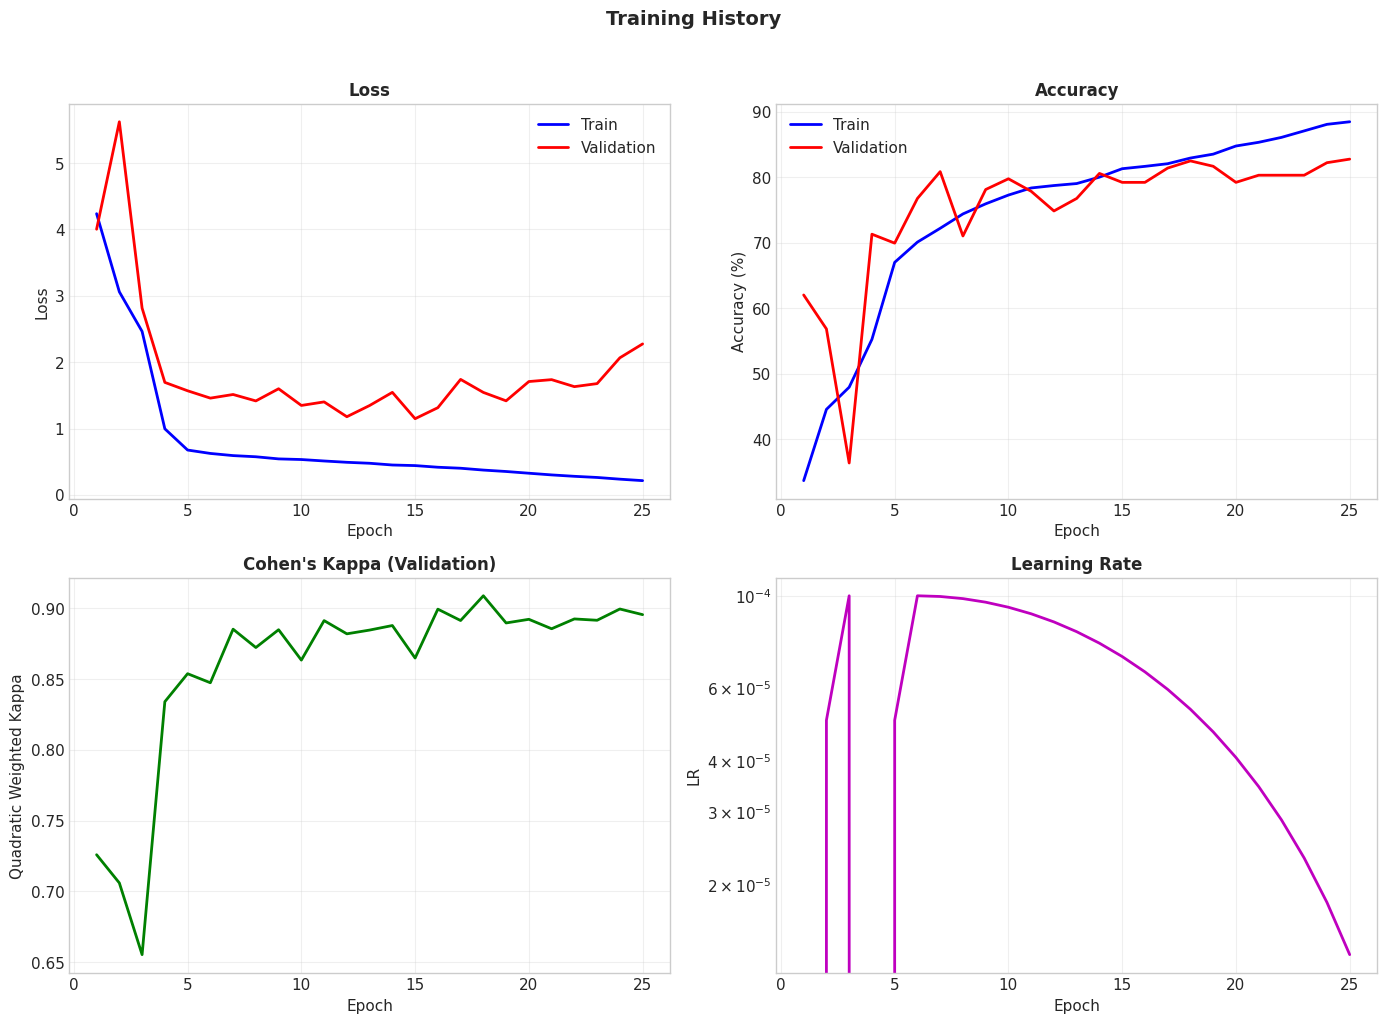

In [27]:
def plot_training_history(history, save_path=None):
    """
    Visualizza le curve di training.
    
    Args:
        history: Dizionario con metriche per epoca
        save_path: Path per salvare la figura (opzionale)
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, 0].set_title('Loss', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Accuracy
    axes[0, 1].plot(epochs, [a*100 for a in history['train_acc']], 'b-', label='Train', linewidth=2)
    axes[0, 1].plot(epochs, [a*100 for a in history['val_acc']], 'r-', label='Validation', linewidth=2)
    axes[0, 1].set_title('Accuracy', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Kappa
    axes[1, 0].plot(epochs, history['val_kappa'], 'g-', linewidth=2)
    axes[1, 0].set_title("Cohen's Kappa (Validation)", fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Learning Rate
    axes[1, 1].plot(epochs, history['lr'], 'm-', linewidth=2)
    axes[1, 1].set_title('Learning Rate', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('LR')
    axes[1, 1].set_yscale('log')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.suptitle('Training History', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figura salvata: {save_path}")
    
    plt.show()


# Visualizza
plot_training_history(history, RESULTS_DIR / 'training_history.png')

## 10. Valutazione Finale

In [28]:
# Carica il miglior modello
# weights_only=False per compatibilita con PyTorch 2.6+
checkpoint_data = torch.load(best_model_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint_data['model_state_dict'])
print(f"Caricato best model (epoch {checkpoint_data['epoch']})")

Caricato best model (epoch 17)


In [29]:
@torch.no_grad()
def evaluate_model(model, loader, device, class_names):
    """
    Valutazione completa del modello.
    
    Args:
        model: Modello PyTorch
        loader: DataLoader
        device: Device
        class_names: Nomi delle classi
        
    Returns:
        metrics: Dizionario con tutte le metriche
    """
    model.eval()
    
    all_preds = []
    all_labels = []
    all_probs = []
    
    for images, labels in tqdm(loader, desc='Evaluating'):
        images = images.to(device)
        outputs = model(images)
        probs = F.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    # Metriche
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'kappa': cohen_kappa_score(all_labels, all_preds, weights='quadratic'),
        'f1_macro': f1_score(all_labels, all_preds, average='macro'),
        'f1_weighted': f1_score(all_labels, all_preds, average='weighted'),
        'f1_per_class': f1_score(all_labels, all_preds, average=None),
        'confusion_matrix': confusion_matrix(all_labels, all_preds),
        'predictions': all_preds,
        'labels': all_labels,
        'probabilities': all_probs
    }
    
    # Report
    print("\n" + "=" * 60)
    print("REPORT VALUTAZIONE")
    print("=" * 60)
    print(f"Accuracy: {metrics['accuracy']*100:.2f}%")
    print(f"Cohen's Kappa (quadratic): {metrics['kappa']:.4f}")
    print(f"F1 Score (macro): {metrics['f1_macro']:.4f}")
    print(f"F1 Score (weighted): {metrics['f1_weighted']:.4f}")
    print("\nF1 Score per classe:")
    for i, f1 in enumerate(metrics['f1_per_class']):
        print(f"  Classe {i} ({class_names[i]}): {f1:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(all_labels, all_preds, 
                                target_names=[class_names[i] for i in range(len(class_names))]))
    
    return metrics

In [30]:
# Valutazione su validation set
print("\n" + "#" * 70)
print("VALUTAZIONE SU VALIDATION SET (APTOS)")
print("#" * 70)
val_metrics = evaluate_model(model, val_loader, DEVICE, CLASS_NAMES)


######################################################################
VALUTAZIONE SU VALIDATION SET (APTOS)
######################################################################


Evaluating:   0%|          | 0/23 [00:00<?, ?it/s]


REPORT VALUTAZIONE
Accuracy: 82.51%
Cohen's Kappa (quadratic): 0.9088
F1 Score (macro): 0.6616
F1 Score (weighted): 0.8159

F1 Score per classe:
  Classe 0 (No DR): 0.9792
  Classe 1 (Mild): 0.6098
  Classe 2 (Moderate): 0.7753
  Classe 3 (Severe): 0.2069
  Classe 4 (Proliferative): 0.7368

Classification Report:
               precision    recall  f1-score   support

        No DR       1.00      0.96      0.98       172
         Mild       0.60      0.62      0.61        40
     Moderate       0.72      0.85      0.78       104
       Severe       0.43      0.14      0.21        22
Proliferative       0.72      0.75      0.74        28

     accuracy                           0.83       366
    macro avg       0.69      0.66      0.66       366
 weighted avg       0.82      0.83      0.82       366



In [31]:
# Valutazione su test set (Messidor-2)
print("\n" + "#" * 70)
print("VALUTAZIONE SU TEST SET (MESSIDOR-2)")
print("#" * 70)
test_metrics = evaluate_model(model, test_loader, DEVICE, CLASS_NAMES)


######################################################################
VALUTAZIONE SU TEST SET (MESSIDOR-2)
######################################################################


Evaluating:   0%|          | 0/109 [00:00<?, ?it/s]


REPORT VALUTAZIONE
Accuracy: 67.14%
Cohen's Kappa (quadratic): 0.7445
F1 Score (macro): 0.6425
F1 Score (weighted): 0.6901

F1 Score per classe:
  Classe 0 (No DR): 0.7770
  Classe 1 (Mild): 0.3982
  Classe 2 (Moderate): 0.6706
  Classe 3 (Severe): 0.6316
  Classe 4 (Proliferative): 0.7353

Classification Report:
               precision    recall  f1-score   support

        No DR       0.91      0.68      0.78      1017
         Mild       0.33      0.50      0.40       270
     Moderate       0.57      0.81      0.67       347
       Severe       0.72      0.56      0.63        75
Proliferative       0.76      0.71      0.74        35

     accuracy                           0.67      1744
    macro avg       0.66      0.65      0.64      1744
 weighted avg       0.74      0.67      0.69      1744



Figura salvata: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/confusion_matrix_val.png


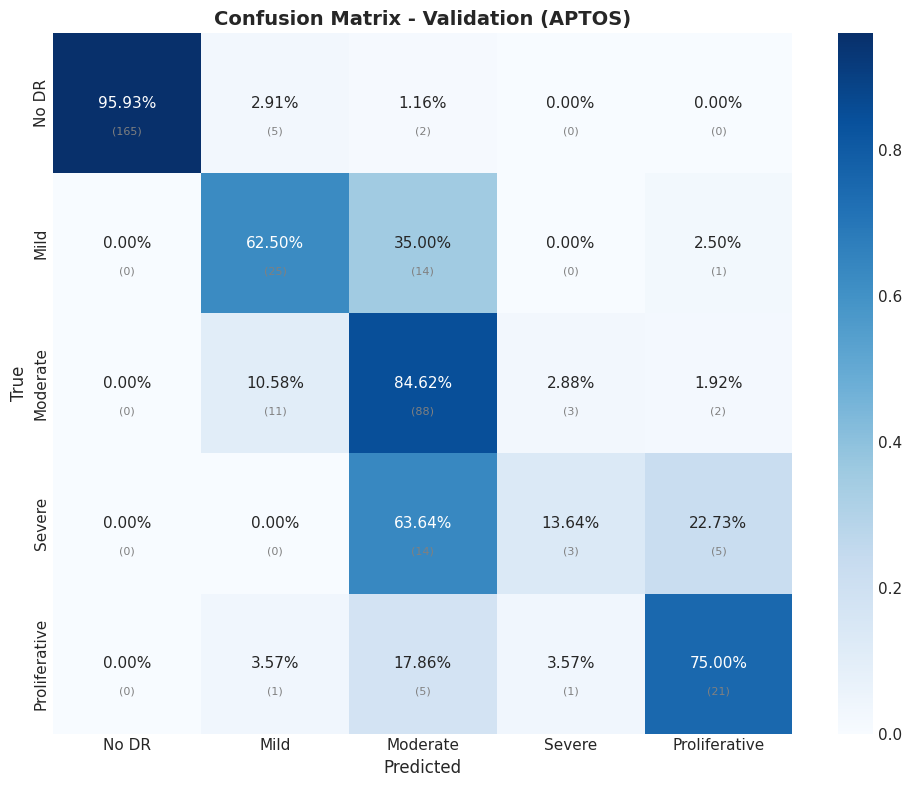

In [32]:
def plot_confusion_matrix(cm, class_names, title='Confusion Matrix', save_path=None):
    """
    Visualizza la matrice di confusione.
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # Normalizza per riga
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    
    sns.heatmap(
        cm_norm, 
        annot=True, 
        fmt='.2%',
        cmap='Blues',
        xticklabels=[class_names[i] for i in range(len(class_names))],
        yticklabels=[class_names[i] for i in range(len(class_names))],
        ax=ax
    )
    
    # Aggiungi conteggi assoluti
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j + 0.5, i + 0.7, f'({cm[i, j]})', 
                   ha='center', va='center', fontsize=8, color='gray')
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=12)
    ax.set_ylabel('True', fontsize=12)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Figura salvata: {save_path}")
    
    plt.show()


# Confusion matrix validation
plot_confusion_matrix(
    val_metrics['confusion_matrix'], 
    CLASS_NAMES,
    title='Confusion Matrix - Validation (APTOS)',
    save_path=RESULTS_DIR / 'confusion_matrix_val.png'
)

Figura salvata: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/confusion_matrix_test.png


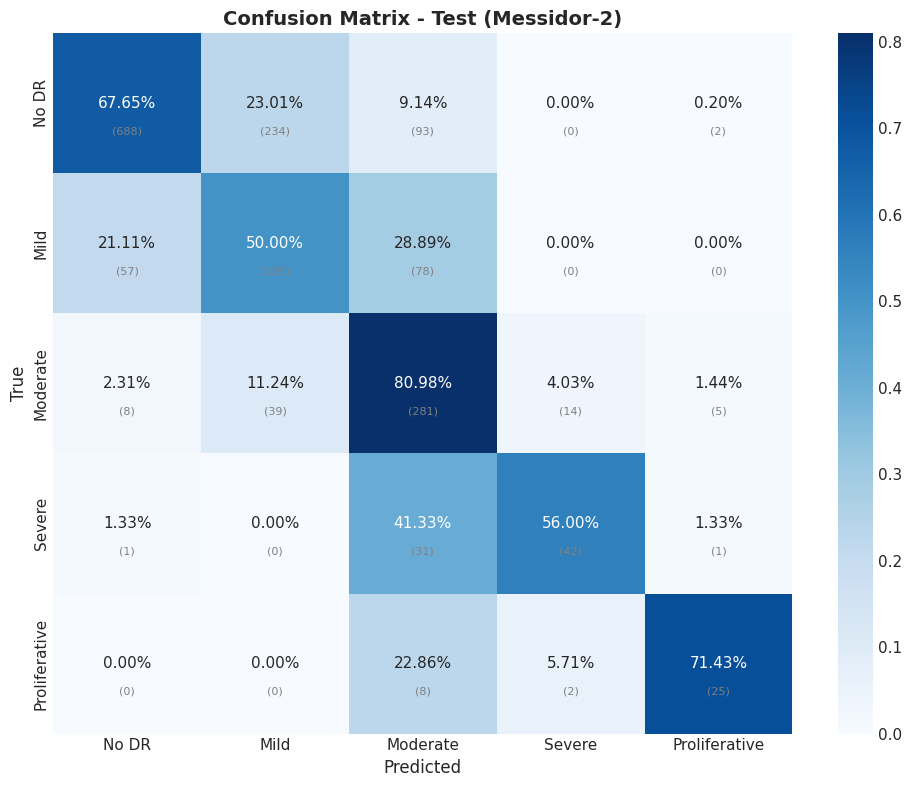

In [33]:
# Confusion matrix test
plot_confusion_matrix(
    test_metrics['confusion_matrix'], 
    CLASS_NAMES,
    title='Confusion Matrix - Test (Messidor-2)',
    save_path=RESULTS_DIR / 'confusion_matrix_test.png'
)

## 11. Salvataggio Artefatti

In [34]:
# Salva history come JSON
history_path = RESULTS_DIR / f'training_history_{timestamp}.json'
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)
print(f"Training history salvato: {history_path}")

# Salva metriche finali
final_metrics = {
    'validation': {
        'accuracy': float(val_metrics['accuracy']),
        'kappa': float(val_metrics['kappa']),
        'f1_macro': float(val_metrics['f1_macro']),
        'f1_weighted': float(val_metrics['f1_weighted']),
        'f1_per_class': val_metrics['f1_per_class'].tolist()
    },
    'test': {
        'accuracy': float(test_metrics['accuracy']),
        'kappa': float(test_metrics['kappa']),
        'f1_macro': float(test_metrics['f1_macro']),
        'f1_weighted': float(test_metrics['f1_weighted']),
        'f1_per_class': test_metrics['f1_per_class'].tolist()
    },
    'config': {
        'model': MODEL_CONFIG['architecture'],
        'epochs_trained': len(history['train_loss']),
        'best_model_path': str(best_model_path)
    }
}

metrics_path = RESULTS_DIR / f'final_metrics_{timestamp}.json'
with open(metrics_path, 'w') as f:
    json.dump(final_metrics, f, indent=2)
print(f"Metriche finali salvate: {metrics_path}")

Training history salvato: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/training_history_20260118_224715.json
Metriche finali salvate: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/final_metrics_20260118_224715.json


In [35]:
# Riepilogo finale
print("\n" + "=" * 70)
print("RIEPILOGO TRAINING")
print("=" * 70)
print(f"\nModello: {MODEL_CONFIG['architecture']}")
print(f"Epoche completate: {len(history['train_loss'])}")
print(f"\nValidation Set (APTOS):")
print(f"  Accuracy: {val_metrics['accuracy']*100:.2f}%")
print(f"  Kappa: {val_metrics['kappa']:.4f}")
print(f"\nTest Set (Messidor-2):")
print(f"  Accuracy: {test_metrics['accuracy']*100:.2f}%")
print(f"  Kappa: {test_metrics['kappa']:.4f}")
print(f"\nArtefatti salvati:")
print(f"  - Best model: {best_model_path}")
print(f"  - Last model: {last_model_path}")
print(f"  - History: {history_path}")
print(f"  - Metrics: {metrics_path}")

# Verifica target
target_acc = 0.90
if val_metrics['accuracy'] >= target_acc:
    print(f"\n[OK] Target accuracy >= {target_acc*100}% RAGGIUNTO!")
else:
    print(f"\n[!] Target accuracy >= {target_acc*100}% non raggiunto ({val_metrics['accuracy']*100:.2f}%)")


RIEPILOGO TRAINING

Modello: efficientnet_b5
Epoche completate: 25

Validation Set (APTOS):
  Accuracy: 82.51%
  Kappa: 0.9088

Test Set (Messidor-2):
  Accuracy: 67.14%
  Kappa: 0.7445

Artefatti salvati:
  - Best model: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/checkpoints/best_model_20260118_224715.pt
  - Last model: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/checkpoints/last_model_20260118_224715.pt
  - History: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/training_history_20260118_224715.json
  - Metrics: /mnt/c/Repository/multi-method-xai-diabetic-retinopathy/results/final_metrics_20260118_224715.json

[!] Target accuracy >= 90.0% non raggiunto (82.51%)


## 12. Conclusioni

### Output Generati

1. **Modelli salvati**:
   - `checkpoints/best_model_*.pt`: Modello con miglior validation kappa
   - `checkpoints/last_model_*.pt`: Ultimo modello dell'epoch finale

2. **Metriche e History**:
   - `results/training_history_*.json`: Loss, accuracy, kappa per ogni epoca
   - `results/final_metrics_*.json`: Metriche finali su validation e test

3. **Visualizzazioni**:
   - `results/training_history.png`: Curve di training
   - `results/confusion_matrix_*.png`: Matrici di confusione

### Prossimi Passi (Fase 2)

1. Implementazione Grad-CAM++ per explainability
2. Validazione su DDR dataset (IoU >= 0.5)
3. Clustering activation patterns